# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Actividad 02: Extracción y Revisión de Datos</center></h1>

Esta actividad busca aplicar lo que acabamos de ver en clases sobre extracción de datos y conectarlo con la materia de "Tipos de Datos" que hemos visto en las clases pasadas.

## Instrucciones

Esto Notebook contiene las instrucciones a realizar para la actividad. 

<b>Al finalizarla, deben subir el Notebook y los archivos generados en un único archivo .zip, al módulo de la Actividad 02 en Canvas.</b>

Para esta actividad deben hacer lo siguiente:
<ol>
<li>Extraer datos</li>

Para esta actividad usaremos [**PokeAPI**](https://pokeapi.co/about), una interfaz de código abierto con información detallada relacionada a los videojuegos de Pokémon.
    
En esta actividad nos concentraremos en comparar las características básicas de los 151 pokémon originales. Para obtener la información de un pokémon, utilizaremos el siguiente URL:

```
https://pokeapi.co/api/v2/pokemon/{id_pokemon}
```

Donde `{id_pokemon}` es el identificador del pokémon (un número entero). 
    
<br>

<li>Formato</li>

¿En qué formato están los datos descargados? Identifique si son datos estructurados, semi-estructurados o no estructurados, explicando claramente por qué los categoriza así.

<br>
    
<li>DataFrame de análisis</li>

Construya un DataFrame con al menos las siguientes columnas: `name, type1, type2, hp, attack, defense, special-attack, special-defense, speed`. En caso de que un pokémon tenga solo un tipo, puede dejar su atributo `type2 = None`. Guarde este nuevo set de datos en un archivo CSV.

**Hint:** Inspeccione el atributo `stats` y `types` de las respuestas obtenidas. El valor que debe almacenar en el DataFrame estará bajó el nombre `base_stat`.
    
<br>
    
<li>Preguntas</li>

A partir de su nuevo dataset, responda las siguientes preguntas:

4.1 ¿Cuál son los 3 tipos (fuego, agua, tierra, etc.) más comunes en los pokémones de la primera generación?
    
4.2 ¿Cuál es el pokémon más rápido? ¿Y el más lento?

4.3 Genere una nueva columna en el DataFrame llamada `total-stats` que consista en la suma de todos los stats de un pokémon (`hp, attack, defense, special-attack, special-defense, speed`) y grafique un histograma de esta nueva variable. ¿Cuál es el rango de valores

## Rúbrica

- Si han hecho todo y sólo hay errores menores: 7.0
- Si sólo llegaron hasta la parte 3: 5.0
- Menos que eso: 1.0

## 1. Extraer datos

Utilizando el URL indicado en el enunciado, obtenga la información de los primeros 151 pokémones y guárdelos en una lista llamada `pokemones`. 

Para ello debe usar un `for` que itere sobre los diferentes IDs de pokemon y rescate la información de cada uno de ellos, concatenándola en una lista. Antes de iterar sobre los 151 pokemones, pruebe con 1 o 2 y una vez que verifique que su código está funcionando, aplique a los 151 primeros pokemones.

In [1]:
import requests
from pathlib import Path
import pandas as pd
from pathlib import Path

In [2]:
pokemones = []
print("Comenzando descarga de 151 pokémones...")

Comenzando descarga de 151 pokémones...


In [3]:
for i in range(1,151):
    try:
        url = f"https://pokeapi.co/api/v2/pokemon/{i}"
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        
        pokemones.append(response.json())
    except Exception as e:
        print(f"Error con Pokémon {i}: {e}")

print(f"\n✅ Descarga completada. Se obtuvieron {len(pokemones)} pokémones")


✅ Descarga completada. Se obtuvieron 150 pokémones


In [4]:
datos_pokemon = {
    "name": [], "type1": [], "type2": [],
    "hp": [], "attack": [], "defense": [],
    "special-attack": [], "special-defense": [], "speed": []
}

In [5]:
for pokemon in pokemones:
    
    # ⭐⭐ LLENAR COLUMNA 'name' ⭐⭐
    datos_pokemon["name"].append(pokemon["name"])
    
    # ⭐⭐ LLENAR COLUMNAS 'type1' y 'type2' ⭐⭐
    types = pokemon["types"]
    type1 = types[0]["type"]["name"]
    type2 = types[1]["type"]["name"] if len(types) > 1 else None
    datos_pokemon["type1"].append(type1)
    datos_pokemon["type2"].append(type2)
    
    # ⭐⭐ CREAR DICCIONARIO TEMPORAL CON STATS ⭐⭐
    stats_dict = {}
    for stat in pokemon["stats"]:
        stat_name = stat["stat"]["name"]
        stats_dict[stat_name] = stat["base_stat"]
    
    # ⭐⭐ LLENAR COLUMNAS DE STATS (hp, attack, etc.) ⭐⭐
    datos_pokemon["hp"].append(stats_dict.get("hp", 0))
    datos_pokemon["attack"].append(stats_dict.get("attack", 0))
    datos_pokemon["defense"].append(stats_dict.get("defense", 0))
    datos_pokemon["special-attack"].append(stats_dict.get("special-attack", 0))
    datos_pokemon["special-defense"].append(stats_dict.get("special-defense", 0))
    datos_pokemon["speed"].append(stats_dict.get("speed", 0))

print("✅ Datos procesados")


✅ Datos procesados


In [6]:
df = pd.DataFrame(datos_pokemon)

# ⭐⭐ GUARDAR COMO CSV ⭐⭐
df.to_csv("pokemon_stats.csv", index=False)

print("✅ DataFrame creado y guardado como 'pokemon_stats.csv'")
print(f"Dimensiones del DataFrame: {df.shape}")
print("\nPrimeras 5 filas:")
print(df.head())

✅ DataFrame creado y guardado como 'pokemon_stats.csv'
Dimensiones del DataFrame: (150, 9)

Primeras 5 filas:
         name  type1   type2  hp  attack  defense  special-attack  \
0   bulbasaur  grass  poison  45      49       49              65   
1     ivysaur  grass  poison  60      62       63              80   
2    venusaur  grass  poison  80      82       83             100   
3  charmander   fire    None  39      52       43              60   
4  charmeleon   fire    None  58      64       58              80   

   special-defense  speed  
0               65     45  
1               80     60  
2              100     80  
3               50     65  
4               65     80  


## 2. Formato de datos

Revise la lista que almacenó en `pokemones` y coméntenos en qué formato están los datos y qué tipos de datos serían estos (estructurados, semi-estructurados, no estructurados).

Respuesta:

Los datos están en un url en donde encontramos formato json siendo datos semi-estructurados

## 3. DataFrame de análisis

Construya ahor un DataFrame para poder analizar los datos posteriormente. Revise las columnas mínimas que debe tener según el enunciado inicial.

In [7]:
import requests
import pandas as pd

## 4. Preguntas

#### 4.1 ¿Cuál son los 3 tipos (*water, fire, ground,* etc.) más comunes en los pokémones de la primera generación?

In [8]:
print("\n🔍 TOP 3 TIPOS MÁS COMUNES:")
all_types = pd.concat([df["type1"], df["type2"].dropna()])
top_3_types = all_types.value_counts().head(3)
print(top_3_types)


🔍 TOP 3 TIPOS MÁS COMUNES:
poison    33
water     32
normal    22
Name: count, dtype: int64


El tipo más común es:

#### 4.2 ¿Cuál es el pokémon más rápido? ¿Y el más lento?

In [9]:
# 4.2 Pokémon más rápido y lento
print("\n⚡ POKÉMÓN MÁS RÁPIDO:")
mas_rapido = df.loc[df["speed"].idxmax()]
print(f"{mas_rapido['name']} (Speed: {mas_rapido['speed']})")

print("\n🐌 POKÉMÓN MÁS LENTO:")
mas_lento = df.loc[df["speed"].idxmin()]
print(f"{mas_lento['name']} (Speed: {mas_lento['speed']})")




⚡ POKÉMÓN MÁS RÁPIDO:
electrode (Speed: 150)

🐌 POKÉMÓN MÁS LENTO:
slowpoke (Speed: 15)


El pokémon más rápido es: "Electrode"

#### 4.3 Genere una nueva columna en el DataFrame llamada `total-stats` que consista en la suma de todos los stats de un pokémon (`hp, attack, defense, special-attack, special-defense, speed`) ¿Cuáles son los valores mínimo y máximo de esta nueva variable?

In [10]:
# 4.3 Total stats
print("\n📊 TOTAL STATS:")
df["total-stats"] = df[["hp", "attack", "defense", "special-attack", "special-defense", "speed"]].sum(axis=1)
print(f"Rango: {df['total-stats'].min()} - {df['total-stats'].max()}")
print(f"Más fuerte: {df.loc[df['total-stats'].idxmax()]['name']}")
print(f"Más débil: {df.loc[df['total-stats'].idxmin()]['name']}")



📊 TOTAL STATS:
Rango: 195 - 680
Más fuerte: mewtwo
Más débil: caterpie


El valor máximo lo tiene:

y el mínimo lo tiene:

#### 4.4 Grafique un histograma de `total-stats` y comente brevemente lo que observa de la distribución de este atributo.

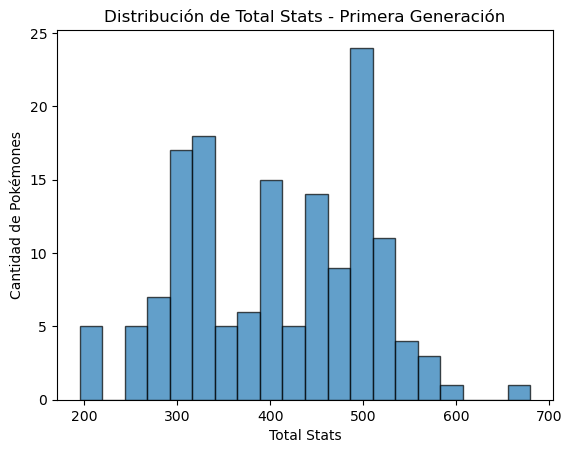

In [11]:
# 4.4 Histograma
import matplotlib.pyplot as plt
plt.hist(df["total-stats"], bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Total Stats")
plt.ylabel("Cantidad de Pokémones")
plt.title("Distribución de Total Stats - Primera Generación")
plt.show()

Descripción: